In [1]:
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

In [2]:
df = pd.read_csv('C:\\Users\\dell\\OneDrive\\Desktop\\data science\\Crop_recommendation.csv')

In [3]:
df.head()

,N,P,K,temperature,humidity,ph,rainfall,label
0,90,42,43,20.879744,82.002744,6.502985,202.935536,rice
1,85,58,41,21.770462,80.319644,7.038096,226.655537,rice
2,60,55,44,23.004459,82.320763,7.840207,263.964248,rice
3,74,35,40,26.491096,80.158363,6.980401,242.864034,rice
4,78,42,42,20.130175,81.604873,7.628473,262.717340,rice


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2200 entries, 0 to 2199
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   N            2200 non-null   int64  
 1   P            2200 non-null   int64  
 2   K            2200 non-null   int64  
 3   temperature  2200 non-null   float64
 4   humidity     2200 non-null   float64
 5   ph           2200 non-null   float64
 6   rainfall     2200 non-null   float64
 7   label        2200 non-null   object 
dtypes: float64(4), int64(3), object(1)
memory usage: 137.6+ KB


In [5]:
df.describe()

,N,P,K,temperature,humidity,ph,rainfall
count,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000
mean,50.551818,53.362727,48.149091,25.616244,71.481779,6.469480,103.463655
std,36.917334,32.985883,50.647931,5.063749,22.263812,0.773938,54.958389
min,0.000000,5.000000,5.000000,8.825675,14.258040,3.504752,20.211267
25%,21.000000,28.000000,20.000000,22.769375,60.261953,5.971693,64.551686
50%,37.000000,51.000000,32.000000,25.598693,80.473146,6.425045,94.867624
75%,84.250000,68.000000,49.000000,28.561654,89.948771,6.923643,124.267508
max,140.000000,145.000000,205.000000,43.675493,99.981876,9.935091,298.560117


In [6]:
df.isnull().sum()

N              0
P              0
K              0
temperature    0
humidity       0
ph             0
rainfall       0
label          0
dtype: int64

In [7]:
corr = df.select_dtypes(include=np.number).corr()
corr

,N,P,K,temperature,humidity,ph,rainfall
N,1.000000,-0.231460,-0.140512,0.026504,0.190688,0.096683,0.059020
P,-0.231460,1.000000,0.736232,-0.127541,-0.118734,-0.138019,-0.063839
K,-0.140512,0.736232,1.000000,-0.160387,0.190859,-0.169503,-0.053461
temperature,0.026504,-0.127541,-0.160387,1.000000,0.205320,-0.017795,-0.030084
humidity,0.190688,-0.118734,0.190859,0.205320,1.000000,-0.008483,0.094423
ph,0.096683,-0.138019,-0.169503,-0.017795,-0.008483,1.000000,-0.109069
rainfall,0.059020,-0.063839,-0.053461,-0.030084,0.094423,-0.109069,1.000000


<Axes: >

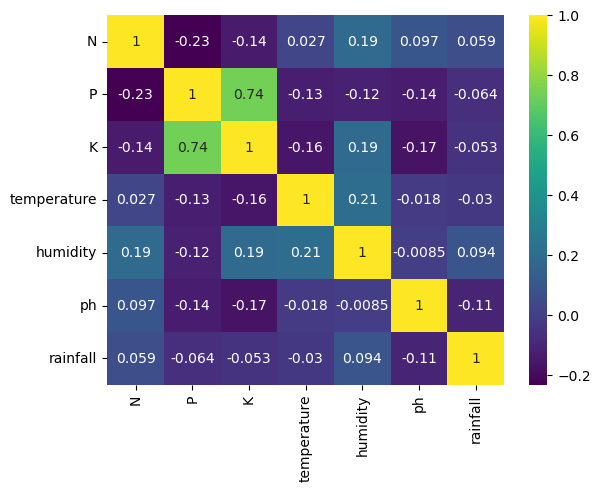

In [8]:
sns.heatmap(corr,cmap='viridis',annot=True)

# Univariate Analysis

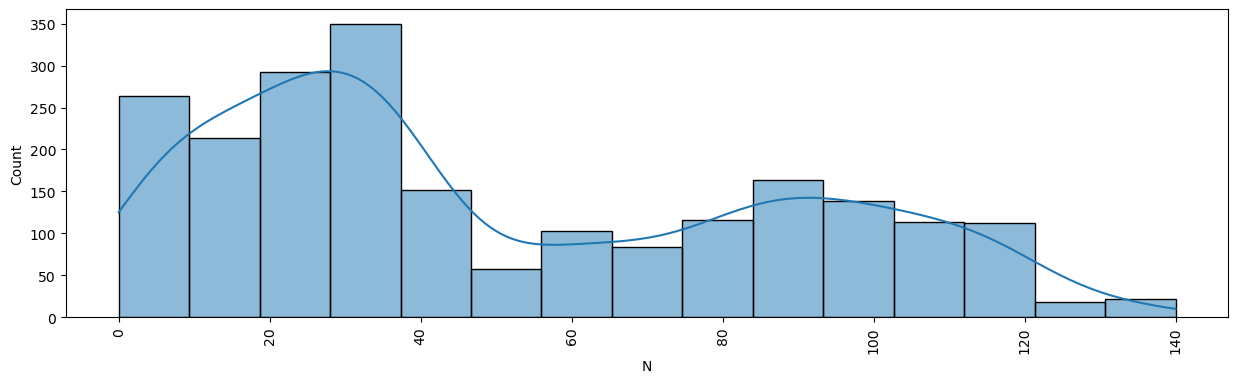

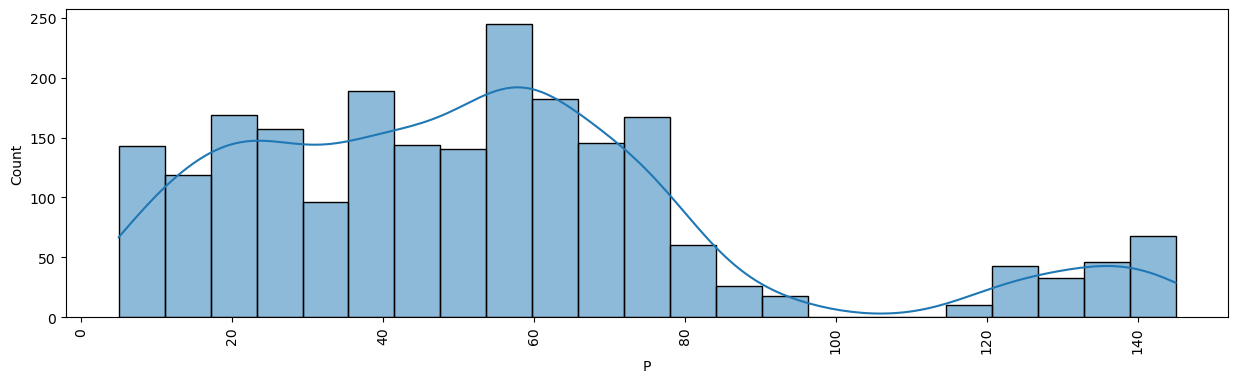

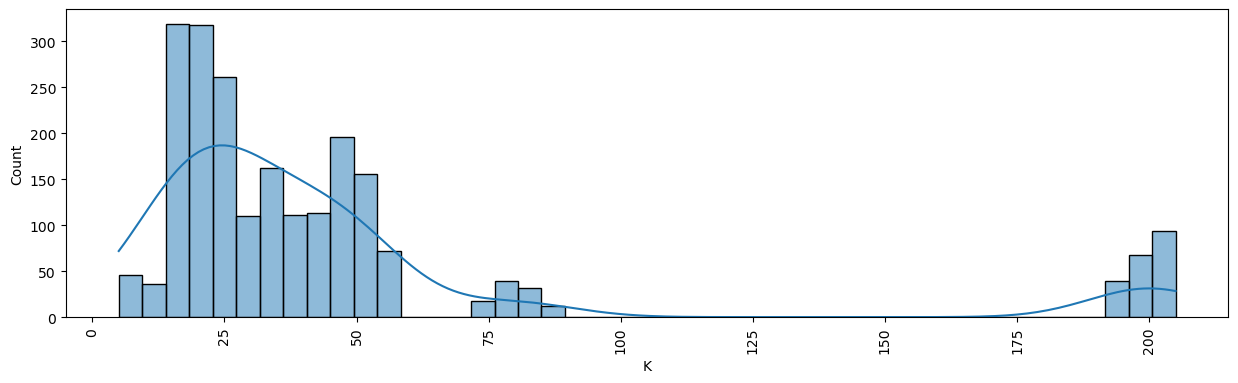

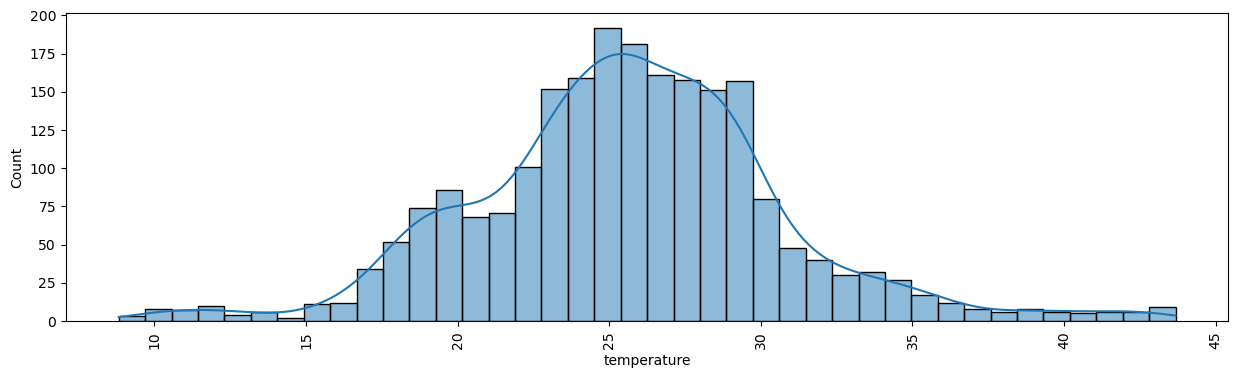

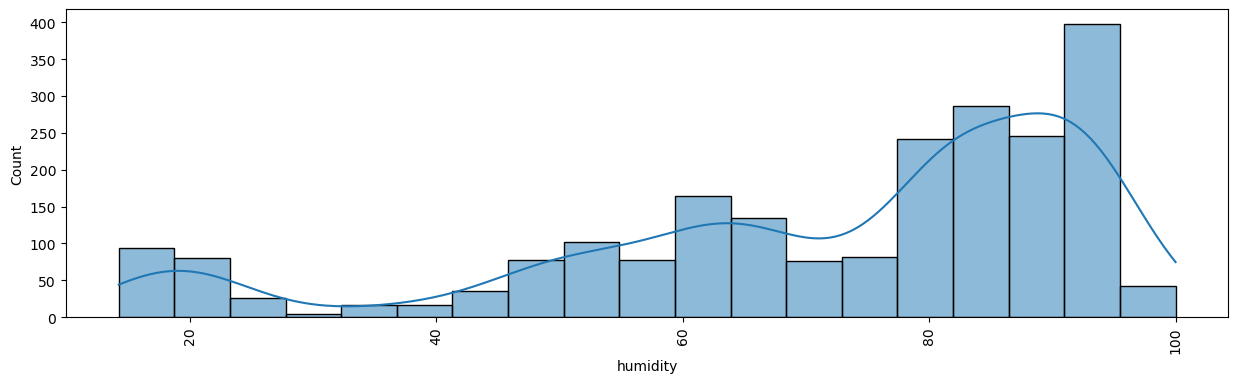

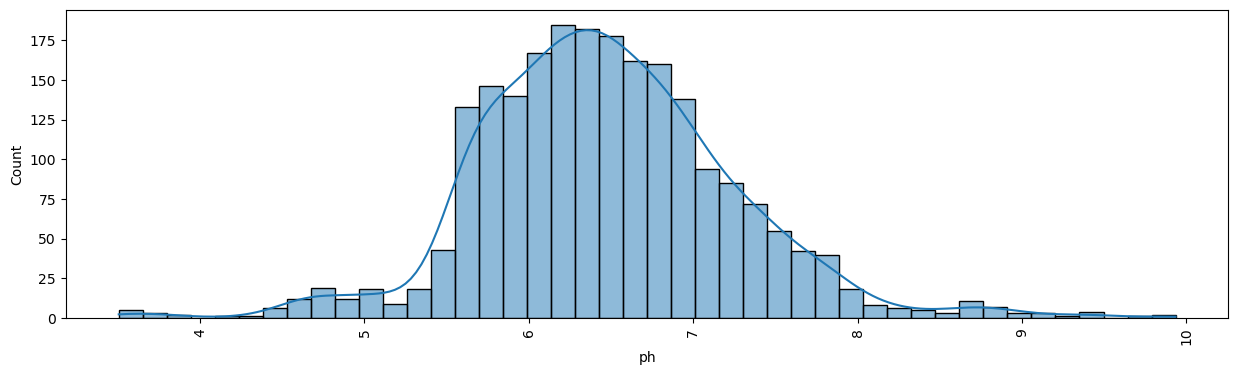

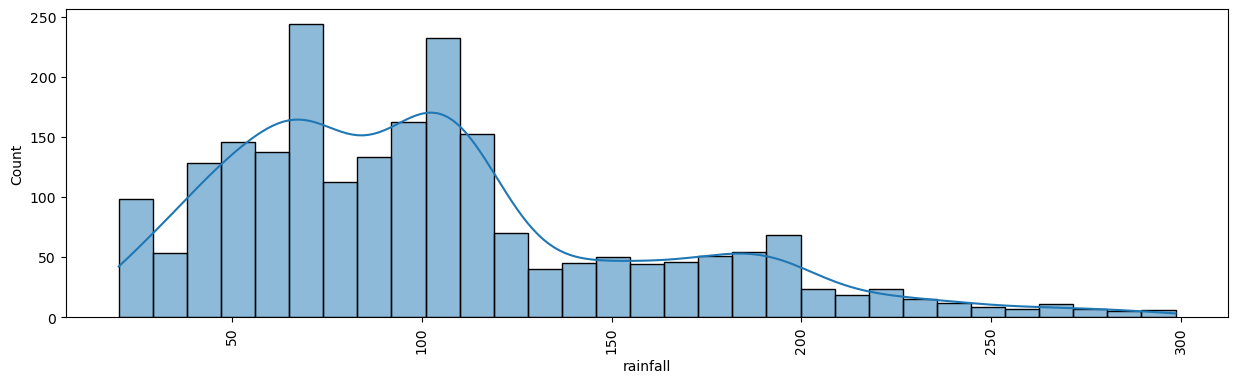

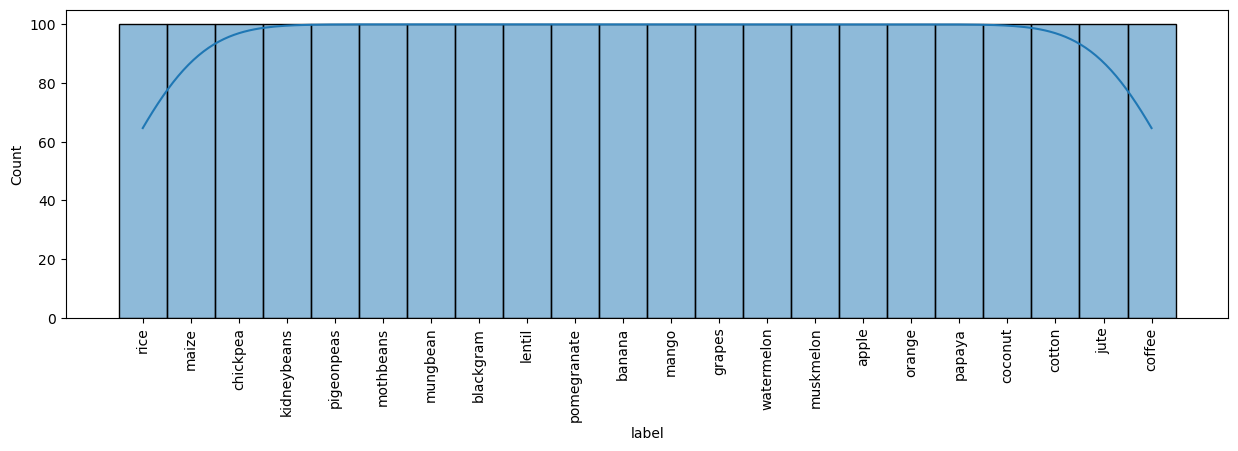

In [9]:
for col in df.columns:
    plt.figure(figsize=(15,4))
    sns.histplot(df,x=col,kde=True)
    plt.xlabel(col)
    plt.xticks(rotation=90)
    plt.show()

## Checking Outliers

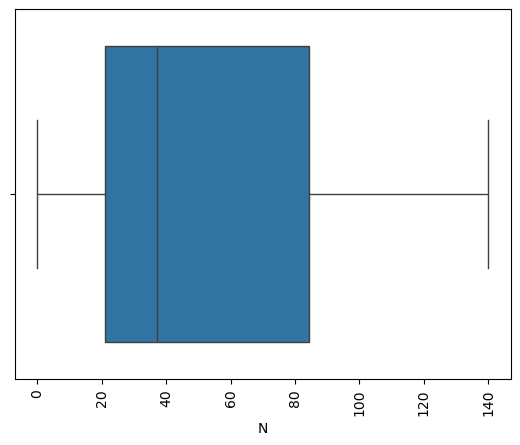

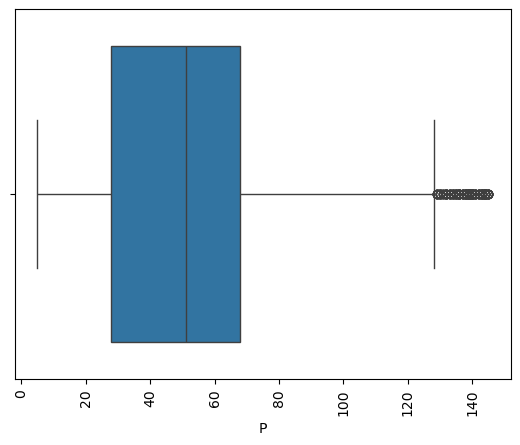

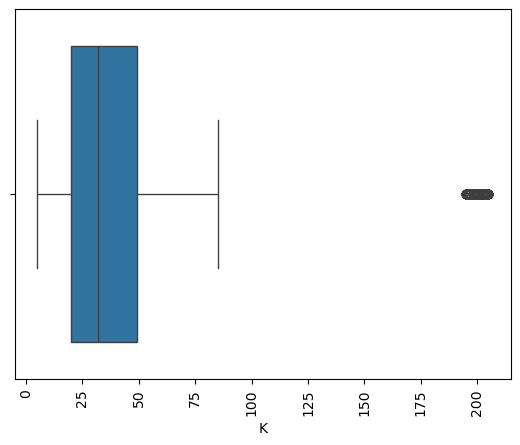

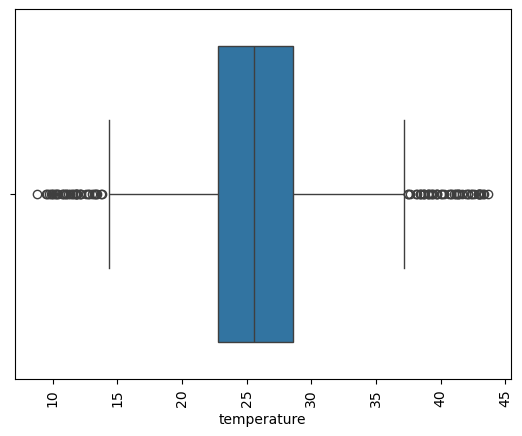

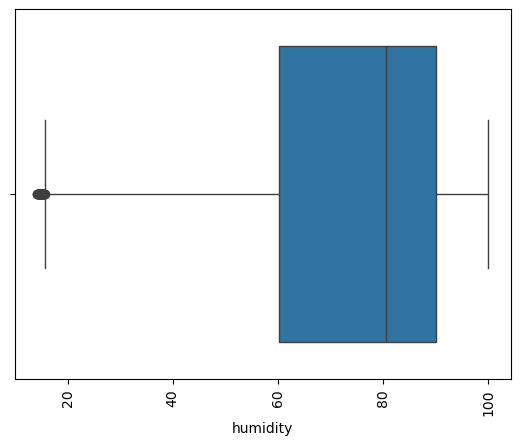

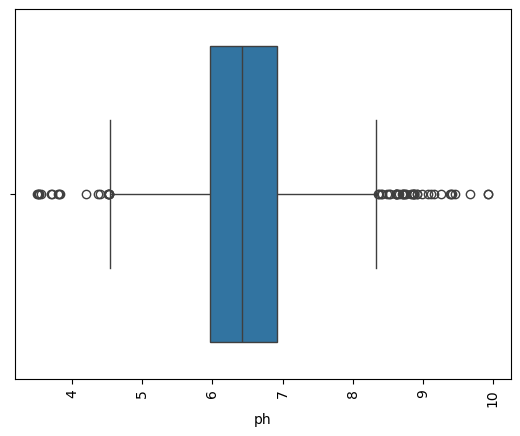

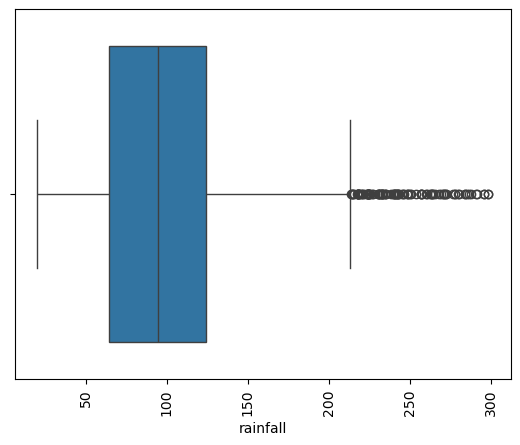

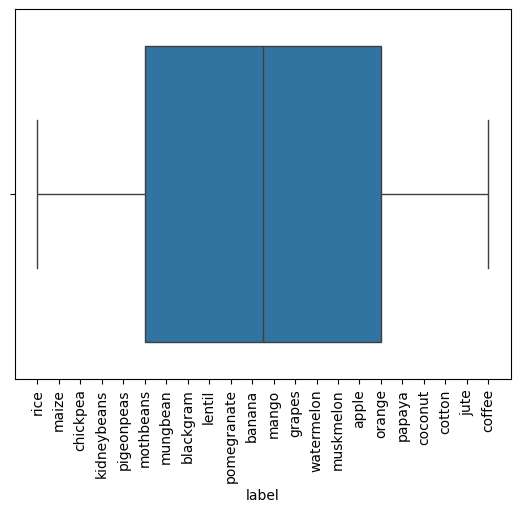

In [18]:
for col in df.columns:
    sns.boxplot(df,x=col)
    plt.xlabel(col)
    plt.xticks(rotation=90)
    plt.show()

## Solving the outliers

In [21]:
def remove_outliers_iqr(df, columns):
    cleaned_df = df.copy()
    
    for col in columns:
        Q1 = cleaned_df[col].quantile(0.25)
        Q3 = cleaned_df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        
        cleaned_df = cleaned_df[(cleaned_df[col] >= lower_bound) & (cleaned_df[col] <= upper_bound)]
    
    return cleaned_df

# Example usage:
numeric_cols = ["N", "P", "K", "temperature", "humidity", "ph", "rainfall"]
df_cleaned = remove_outliers_iqr(df, numeric_cols)

In [23]:
df_cleaned.head()

,N,P,K,temperature,humidity,ph,rainfall,label
0,90,42,43,20.879744,82.002744,6.502985,202.935536,rice
1,85,58,41,21.770462,80.319644,7.038096,226.655537,rice
3,74,35,40,26.491096,80.158363,6.980401,242.864034,rice
7,94,53,40,20.277744,82.894086,5.718627,241.974195,rice
8,89,54,38,24.515881,83.535216,6.685346,230.446236,rice


<Axes: xlabel='temperature'>

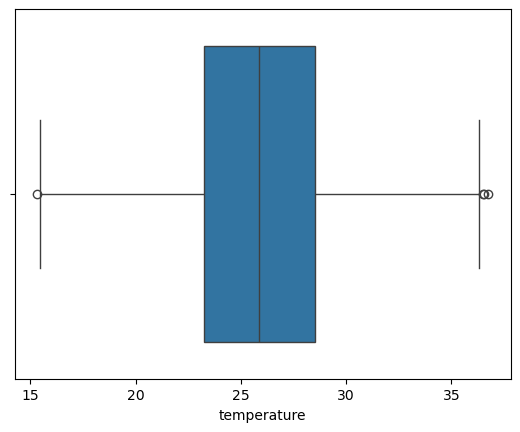

In [26]:
sns.boxplot(df_cleaned,x='temperature')

## Observations:
- outliers are removed.

In [31]:
df_cleaned.label.value_counts()

label
banana         100
pomegranate    100
jute           100
cotton         100
coconut        100
muskmelon      100
watermelon     100
maize          100
coffee         100
lentil         100
blackgram      100
mungbean       100
kidneybeans    100
mango           96
pigeonpeas      96
chickpea        88
orange          81
papaya          63
rice            62
mothbeans       60
Name: count, dtype: int64

- the value distribution of `output` fearure is good and we can consider this as `balanced dataset`

## considering the inputs and targets.

In [33]:
inputs = df.iloc[:,:-1]
targets = df.iloc[:,-1]

In [34]:
inputs.head()

,N,P,K,temperature,humidity,ph,rainfall
0,90,42,43,20.879744,82.002744,6.502985,202.935536
1,85,58,41,21.770462,80.319644,7.038096,226.655537
2,60,55,44,23.004459,82.320763,7.840207,263.964248
3,74,35,40,26.491096,80.158363,6.980401,242.864034
4,78,42,42,20.130175,81.604873,7.628473,262.717340


In [36]:
targets.head()

0    rice
1    rice
2    rice
3    rice
4    rice
Name: label, dtype: object

## Scaling the numerical inputs.

In [37]:
from sklearn.preprocessing import MinMaxScaler

In [38]:
X = MinMaxScaler().fit_transform(inputs)

In [42]:
X=pd.DataFrame(X,columns=inputs.columns)

In [43]:
X.head()

,N,P,K,temperature,humidity,ph,rainfall
0,0.642857,0.264286,0.190,0.345886,0.790267,0.466264,0.656458
1,0.607143,0.378571,0.180,0.371445,0.770633,0.549480,0.741675
2,0.428571,0.357143,0.195,0.406854,0.793977,0.674219,0.875710
3,0.528571,0.214286,0.175,0.506901,0.768751,0.540508,0.799905
4,0.557143,0.264286,0.185,0.324378,0.785626,0.641291,0.871231


## Splitting training and Evaluting

In [45]:
from sklearn.model_selection import train_test_split

In [47]:
X_train,X_test,y_train,y_test = train_test_split(X,targets,test_size=0.3,random_state=42)

In [48]:
X_train.shape,X_test.shape,y_train.shape,y_test.shape 

((1540, 7), (660, 7), (1540,), (660,))

In [49]:
from sklearn.linear_model import LogisticRegression

In [50]:
model = LogisticRegression().fit(X_train,y_train)

In [53]:
preds = model.predict(X_test)


In [54]:
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report

In [55]:
accuracy_score(y_test,preds)

0.9287878787878788

In [57]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# y_true = actual labels
# y_pred = predicted labels

print("Accuracy:", accuracy_score(y_test,preds))
print("\nClassification Report:\n", classification_report(y_test,preds))
print("\nConfusion Matrix:\n", confusion_matrix(y_test,preds))

Accuracy: 0.9287878787878788

Classification Report:
               precision    recall  f1-score   support

       apple       1.00      1.00      1.00        34
      banana       1.00      1.00      1.00        26
   blackgram       0.85      0.85      0.85        26
    chickpea       1.00      1.00      1.00        34
     coconut       1.00      1.00      1.00        33
      coffee       0.97      1.00      0.98        30
      cotton       0.97      1.00      0.98        28
      grapes       1.00      1.00      1.00        23
        jute       0.96      0.68      0.79        34
 kidneybeans       0.95      1.00      0.97        36
      lentil       0.79      1.00      0.88        22
       maize       1.00      0.96      0.98        26
       mango       0.73      1.00      0.84        32
   mothbeans       1.00      0.59      0.74        34
    mungbean       0.86      1.00      0.92        30
   muskmelon       1.00      1.00      1.00        24
      orange       0.96    

In [58]:
from sklearn.tree import DecisionTreeClassifier

In [72]:
model1 = DecisionTreeClassifier( criterion='gini',        # or 'entropy'
    max_depth=None,          # let tree expand fully first
    min_samples_split=2,     # default
    min_samples_leaf=1,      # default
    max_features=None,       # use all features
    random_state=42      # or 'sqrt', 'log2'
                ).fit(X_train,y_train)

In [73]:
preds1 = model1.predict(X_test)

In [74]:
print("Accuracy:", accuracy_score(y_test,preds1))
print("\nClassification Report:\n", classification_report(y_test,preds1))
print("\nConfusion Matrix:\n", confusion_matrix(y_test,preds1))

Accuracy: 0.9863636363636363

Classification Report:
               precision    recall  f1-score   support

       apple       1.00      1.00      1.00        34
      banana       1.00      1.00      1.00        26
   blackgram       0.96      1.00      0.98        26
    chickpea       1.00      1.00      1.00        34
     coconut       1.00      1.00      1.00        33
      coffee       1.00      1.00      1.00        30
      cotton       1.00      1.00      1.00        28
      grapes       1.00      1.00      1.00        23
        jute       0.86      0.94      0.90        34
 kidneybeans       1.00      1.00      1.00        36
      lentil       0.96      1.00      0.98        22
       maize       1.00      1.00      1.00        26
       mango       1.00      1.00      1.00        32
   mothbeans       1.00      0.94      0.97        34
    mungbean       1.00      1.00      1.00        30
   muskmelon       1.00      1.00      1.00        24
      orange       1.00    

In [77]:
from sklearn.ensemble import RandomForestClassifier

In [88]:
model2 = RandomForestClassifier(n_estimators=100,max_depth=6,n_jobs=-1,random_state=42).fit(X_train,y_train)

In [89]:
preds2 = model2.predict(X_test)

In [90]:
print("Accuracy:", accuracy_score(y_test,preds2))
print("\nClassification Report:\n", classification_report(y_test,preds2))
print("\nConfusion Matrix:\n", confusion_matrix(y_test,preds2))

Accuracy: 0.9893939393939394

Classification Report:
               precision    recall  f1-score   support

       apple       1.00      1.00      1.00        34
      banana       1.00      1.00      1.00        26
   blackgram       0.93      1.00      0.96        26
    chickpea       1.00      1.00      1.00        34
     coconut       1.00      1.00      1.00        33
      coffee       1.00      1.00      1.00        30
      cotton       1.00      1.00      1.00        28
      grapes       1.00      1.00      1.00        23
        jute       0.87      1.00      0.93        34
 kidneybeans       1.00      1.00      1.00        36
      lentil       1.00      1.00      1.00        22
       maize       1.00      1.00      1.00        26
       mango       1.00      1.00      1.00        32
   mothbeans       1.00      0.94      0.97        34
    mungbean       1.00      1.00      1.00        30
   muskmelon       1.00      1.00      1.00        24
      orange       1.00    